# Logistic Regression — từ công thức toán đến code (4 giai đoạn) trên Diamonds

**Môn học:** Học máy nâng cao (ml_ad) · **Học viên:** Nguyễn Phương Anh Tú · **MSHV:** 2611328

> **Phương pháp của môn (áp dụng cho mọi thuật toán).** Notebook triển khai theo đúng 4 giai đoạn:
> 1. **Giải tay** — dẫn kiến thức toán từng bước trước khi viết mã, kèm ví dụ số cụ thể và sơ đồ.
> 2. **Bản thuần, KHÔNG thư viện** — cài từ công thức bằng NumPy, kiểm chứng gradient bằng sai phân hữu hạn.
> 3. **Bản thư viện** — `scikit-learn`.
> 4. **Bản framework** — `PyTorch` (sau cùng).
>
> Bốn cách cho cùng kết quả trên cùng dữ liệu — minh chứng bản thuần cài **đúng**.

**Bộ dữ liệu.** `diamonds` (Kaggle/seaborn, 53940 viên kim cương thực tế, dùng chung cho cả 3 notebook Linear/Logistic/Softmax của đợt bài này) có **đúng 2 cột nhãn** được dùng:
- `price` (giá bán, **LIÊN TỤC**) — dùng cho hồi quy tuyến tính (notebook khác).
- `cut` (chất lượng cắt, **RỜI RẠC**, 5 mức `Fair < Good < Very Good < Premium < Ideal`) — dùng nguyên cho Softmax (notebook khác), hoặc **nhị phân hoá "Ideal hay không"** cho notebook Logistic này.

**8 đặc trưng dùng chung** (giống hệt 2 notebook kia để về sau ghép vào một mạng multi-task): `carat, depth, table, x, y, z` (đo đạc vật lý) và `color_ord, clarity_ord` (màu sắc, độ tinh khiết — đã mã hoá thứ bậc từ xấu đến tốt).

**Bài toán của notebook này:** dự đoán nhị phân $y \in \{0,1\}$ — viên kim cương có cắt **Ideal** hay không — từ 8 đặc trưng trên. Đây là notebook Logistic Regression **đầu tiên** của môn (các bài trước chỉ có Softmax); Mục 1 dưới đây chỉ rõ quan hệ giữa hai mô hình.

Vì `carat` và `x, y, z` tương quan cao (đa cộng tuyến vừa phải — condition number của ma trận đặc trưng sau chuẩn hoá $\approx 624$), bài toán hồi quy **giá** (tuyến tính) cần rất nhiều epoch mới hội tụ khớp bản thư viện. Notebook này dùng **chung một ma trận đặc trưng X** nhưng nhãn khác (nhị phân thay vì giá liên tục) — Mục 8 sẽ giải thích trung thực vì sao logistic lại hội tụ sạch và nhanh hơn nhiều dù cùng đặc trưng.

## 0. Nạp dữ liệu diamonds và tiền xử lý (dùng CHUNG cho cả 3 notebook)

Khối tiền xử lý dưới đây **giống hệt (byte-identical)** ở cả 3 notebook Linear/Logistic/Softmax: cùng cách đọc dữ liệu, cùng lọc dòng lỗi, cùng mã hoá thứ bậc, cùng `train_test_split` với `random_state=1`, cùng chuẩn hoá — để dữ liệu train/test khớp hàng khi ghép vào notebook multi-task sau này.

In [1]:
%matplotlib inline
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

_cands = ["data/diamonds.csv", "../data/diamonds.csv",
          "/home/alexdev/Projects/learning-master-ute/ml_ad/b8/data/diamonds.csv"]
CSV = next((p for p in _cands if os.path.exists(p)), _cands[0])
df = pd.read_csv(CSV)
df = df[(df.x > 0) & (df.y > 0) & (df.z > 0)].reset_index(drop=True)  # drop 20 malformed rows

color_order = {c: i for i, c in enumerate(["J", "I", "H", "G", "F", "E", "D"])}       # J te nhat -> D tot nhat
clarity_order = {c: i for i, c in enumerate(["I1","SI2","SI1","VS2","VS1","VVS2","VVS1","IF"])}  # I1 te nhat -> IF tot nhat
cut_order = {c: i for i, c in enumerate(["Fair", "Good", "Very Good", "Premium", "Ideal"])}
df["color_ord"] = df["color"].map(color_order)
df["clarity_ord"] = df["clarity"].map(clarity_order)
df["cut_ord"] = df["cut"].map(cut_order)

FEAT_COLS = ["carat", "depth", "table", "x", "y", "z", "color_ord", "clarity_ord"]  # 8 dac trung dung chung
X = df[FEAT_COLS].values.astype(float)
y_price = df["price"].values.astype(float)          # nhan LIEN TUC
y_bin = (df["cut"] == "Ideal").astype(int).values    # nhan ROI RAC (nhi phan, tu cot 'cut')
y_multi = df["cut_ord"].values                       # nhan ROI RAC (5 lop, cung cot 'cut')

Xtr, Xte, ptr, pte, btr, bte, mtr, mte = train_test_split(
    X, y_price, y_bin, y_multi, test_size=0.2, random_state=1, stratify=y_multi
)
mu, sd = Xtr.mean(axis=0), Xtr.std(axis=0)
Xtr_s, Xte_s = (Xtr - mu) / sd, (Xte - mu) / sd

print("So dac trung:", FEAT_COLS)
print("Kich thuoc train/test:", Xtr_s.shape, Xte_s.shape)
print("Ti le lop Ideal (y_bin=1): train = %.4f | test = %.4f" % (btr.mean(), bte.mean()))
print("=> mat can bang lop nhe (~%.0f%% Ideal / %.0f%% khong Ideal)" % (100*btr.mean(), 100*(1-btr.mean())))

So dac trung: ['carat', 'depth', 'table', 'x', 'y', 'z', 'color_ord', 'clarity_ord']
Kich thuoc train/test: (43136, 8) (10784, 8)
Ti le lop Ideal (y_bin=1): train = 0.3996 | test = 0.3997
=> mat can bang lop nhe (~40% Ideal / 60% khong Ideal)


## 1. Hồi quy Logistic là trường hợp đặc biệt K=2 của hồi quy Softmax

Notebook Softmax (bài khác trong đợt này) trình bày mô hình cho $K$ lớp: mỗi lớp $k$ có logit riêng $z_k = w_k\cdot x + b_k$, xác suất lớp $k$ là

$$\hat{y}_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}.$$

Khi $K=2$ (ở đây: "Ideal" so với "không Ideal"), xác suất lớp 1 ("Ideal") là

$$p_1 = \frac{e^{z_1}}{e^{z_0}+e^{z_1}}.$$

Chia cả tử và mẫu cho $e^{z_0}$ (khử được $e^{z_0}$):

$$p_1 = \frac{e^{z_1}/e^{z_0}}{1 + e^{z_1}/e^{z_0}} = \frac{1}{1+e^{-(z_1-z_0)}}.$$

Đặt $z := z_1 - z_0$ (hiệu hai logit — **log-odds**), ta được đúng hàm **sigmoid**:

$$p_1 = \sigma(z) = \frac{1}{1+e^{-z}}.$$

Vì chỉ hiệu $z_1 - z_0$ quyết định $p_1$ (cộng cùng một hằng số vào cả $z_0, z_1$ không đổi kết quả — hai bộ tham số $(w_0,b_0),(w_1,b_1)$ là **dư thừa**), quy ước chuẩn của hồi quy logistic là bỏ luôn cặp tham số dư, chỉ tham số hoá **trực tiếp một log-odds duy nhất** $z = w\cdot x + b$ với một vector trọng số $w$ (8 chiều) thay vì hai. Đây **cùng một mô hình toán** với softmax $K=2$ — chỉ gọn hơn về tham số.

## 2. Mô hình và hàm mất mát

**Log-odds (logit).** Với trọng số $w \in \mathbb{R}^{8}$ và thiên lệch $b \in \mathbb{R}$:
$$z = w\cdot x + b \in \mathbb{R}.$$

**Sigmoid** biến log-odds thành xác suất $p \in (0,1)$ — xác suất viên kim cương có `cut = Ideal`:
$$p = \sigma(z) = \frac{1}{1+e^{-z}}.$$

**Mất mát entropy chéo nhị phân (binary cross-entropy)** của một mẫu, nhãn thật $y \in \{0,1\}$:
$$\ell = -\big[y\log p + (1-y)\log(1-p)\big].$$

Trên cả tập $N$ mẫu, cực tiểu hoá $\mathcal{L} = \tfrac{1}{N}\sum_i \ell_i$.

## 3. GIẢI TAY — dẫn xuất gradient từng bước

Mục tiêu: tính $\partial\mathcal{L}/\partial w$ và $\partial\mathcal{L}/\partial b$.

**Bước 1. Đạo hàm sigmoid.** Từ $p = 1/(1+e^{-z})$, đạo hàm chuẩn:
$$\frac{\partial p}{\partial z} = p(1-p).$$

**Bước 2. Đạo hàm mất mát theo log-odds (quy tắc chuỗi).** Với $\ell = -[y\log p + (1-y)\log(1-p)]$:
$$\frac{\partial \ell}{\partial z} = \frac{\partial \ell}{\partial p}\cdot\frac{\partial p}{\partial z} = -\Big[\frac{y}{p} - \frac{1-y}{1-p}\Big]\cdot p(1-p) = -\big[y(1-p) - (1-y)p\big] = p - y.$$

$$\boxed{\;\frac{\partial \ell}{\partial z} = p - y\;}$$

— **y hệt** công thức gradient logit $\partial\ell/\partial z_m = \hat{y}_m - y_m$ của softmax khi $K=2$: thêm một minh chứng logistic là trường hợp riêng của softmax.

**Bước 3. Theo trọng số và thiên lệch.** Vì $z = w\cdot x + b$:
$$\frac{\partial \ell}{\partial w_j} = x_j\,(p-y), \qquad \frac{\partial \ell}{\partial b} = p - y.$$

**Bước 4. Gộp cả batch.** Đặt $\mathbf{p},\mathbf{y}\in\mathbb{R}^N$ (một số cho mỗi mẫu), $X\in\mathbb{R}^{N\times 8}$:

$$\boxed{\;\frac{\partial \mathcal{L}}{\partial w} = \frac{1}{N} X^\top(\mathbf{p}-\mathbf{y}), \qquad \frac{\partial \mathcal{L}}{\partial b} = \frac{1}{N}\mathbf{1}^\top(\mathbf{p}-\mathbf{y})\;}$$

Cùng dạng gradient "đẹp" như softmax: sai số dự đoán trừ nhãn, không cần đạo hàm bậc hai. Mục tiếp theo thay số cụ thể rồi kiểm chứng bằng **sai phân hữu hạn**.

### 3bis. Giải tay với số cụ thể (thay số vào công thức)

Lấy đúng viên kim cương đầu tiên trong tập train (đã chuẩn hoá 8 đặc trưng) để thay số.

**Bảng ý nghĩa từng kí hiệu:**

| Kí hiệu | Đọc là | Ý nghĩa | Kích thước | Giá trị ở mẫu này |
|---|---|---|---|---|
| `x` | "x" | vector 8 đặc trưng đã chuẩn hoá (carat, depth, table, x, y, z, color_ord, clarity_ord) | (8,) | [-0.986, 0.104, -0.649, -1.170, -1.155, -1.134, 1.524, -0.032] |
| `w` | "w" | vector trọng số — mức đóng góp của từng đặc trưng vào log-odds | (8,) | [0.5, -0.2, 0.1, 0.3, -0.1, 0.2, 0.4, 0.3] (minh hoạ, chưa học) |
| `b` | "b" | thiên lệch (bias) | số | 0.1 (minh hoạ) |
| `z = w·x + b` | "z" | **log-odds** (điểm số thô); dương → nghiêng về Ideal, âm → nghiêng về không Ideal | số | -0.3407 |
| `p = σ(z)` | "p" | **xác suất** dự đoán "là Ideal" | số, (0,1) | 0.4156 |
| `y` | "y" | nhãn thật (1 nếu Ideal, 0 nếu không) | số ∈ {0,1} | 1 (viên này thực sự Ideal) |
| `ℓ = -[y log p + (1-y) log(1-p)]` | "ell" | mất mát entropy chéo nhị phân | số | 0.8779 |
| `∂ℓ/∂z = p − y` | "grad-z" | đạo hàm mất mát theo log-odds — hướng cần sửa | số | -0.5844 |

**Đầu vào cụ thể.** `x = [-0.986, 0.104, -0.649, -1.170, -1.155, -1.134, 1.524, -0.032]`, nhãn thật `y = 1` (Ideal). Trọng số minh hoạ (chọn tay, KHÔNG phải trọng số đã học): `w = [0.5, -0.2, 0.1, 0.3, -0.1, 0.2, 0.4, 0.3]`, `b = 0.1`.

**Bước 1 — Tích vô hướng `z = w·x + b`** (mỗi số hạng = 1 trọng số nhân 1 đặc trưng):
- `w0*x0 = 0.5 * -0.986   = -0.4930`  (carat)
- `w1*x1 = -0.2 * 0.104   = -0.0207`  (depth)
- `w2*x2 = 0.1 * -0.649   = -0.0649`  (table)
- `w3*x3 = 0.3 * -1.170   = -0.3510`  (x)
- `w4*x4 = -0.1 * -1.155  =  0.1155`  (y)
- `w5*x5 = 0.2 * -1.134   = -0.2267`  (z)
- `w6*x6 = 0.4 * 1.524    =  0.6096`  (color_ord)
- `w7*x7 = 0.3 * -0.032   = -0.0095`  (clarity_ord)

Tổng = `-0.4407`, cộng `b = 0.1` → `z = -0.3407`.

**Bước 2 — Sigmoid `p = 1/(1+e^-z)`:**
`e^-z = e^0.3407 = 1.4058`, nên `p = 1/(1+1.4058) = 0.4156`
→ mô hình (minh hoạ, chưa học) đoán xác suất "Ideal" chỉ 41.6% dù nhãn thật là Ideal — chưa tốt, đúng như kỳ vọng vì `w,b` là số chọn tay, không phải kết quả huấn luyện.

**Bước 3 — Mất mát entropy chéo nhị phân.** Vì `y=1`, số hạng `(1-y) log(1-p)` triệt tiêu, chỉ còn:
`ℓ = -log(p) = -log(0.4156) = 0.8779`

**Bước 4 — Gradient `∂ℓ/∂z = p - y`:**
`∂ℓ/∂z = 0.4156 - 1 = -0.5844`
Âm ⇒ hàm mất mát **giảm** nếu `z` **tăng** ⇒ gradient descent sẽ đẩy `z` tăng lên, làm `p` tiến gần 1 hơn — đúng hướng vì nhãn thật `y=1`.

**Bước 5 — Gradient theo trọng số `∂ℓ/∂w = (p-y)·x`:**
`∂ℓ/∂w = -0.5844 * x = [0.5762, -0.0605, 0.3794, 0.6837, 0.6751, 0.6624, -0.8906, 0.0185]`,  `∂ℓ/∂b = -0.5844`

Cell kế tiếp chạy đúng các con số trên bằng mã, kiểm chứng gradient bằng **sai phân hữu hạn**, rồi **vẽ sơ đồ** luồng tính toán.

In [2]:
# === Giai doan 1: GIAI TAY tren 1 mau ===
x0 = Xtr_s[0].astype(float)
w0 = np.array([0.5, -0.2, 0.1, 0.3, -0.1, 0.2, 0.4, 0.3])   # trong so minh hoa, CHUA hoc
b0 = 0.1
print("x0 (8 dac trung da chuan hoa) =", np.round(x0, 4))

z0 = w0 @ x0 + b0
print("z0 = w0.x0 + b0 =", round(z0, 4))

p0 = 1 / (1 + np.exp(-z0))
print("p0 = sigmoid(z0) =", round(p0, 4))

y0 = float(btr[0])
print("y0 (nhan that, 1=Ideal) =", y0)

loss0 = -(y0 * np.log(p0) + (1 - y0) * np.log(1 - p0))
print("loss0 (BCE) =", round(loss0, 4))

grad_z0 = p0 - y0
print("dL/dz0 = p0 - y0 =", round(grad_z0, 4))
grad_w0 = grad_z0 * x0
print("dL/dw0 =\n", np.round(grad_w0, 4))
print("dL/db0 =", round(grad_z0, 4))

# === Kiem chung gradient bang sai phan huu han ===
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def loss_single(w, b):
    z = w @ x0 + b
    p = sigmoid(z)
    return -(y0 * np.log(p) + (1 - y0) * np.log(1 - p))

eps = 1e-6
gw_num = np.zeros_like(w0)
for i in range(len(w0)):
    wp = w0.copy(); wp[i] += eps
    wm = w0.copy(); wm[i] -= eps
    gw_num[i] = (loss_single(wp, b0) - loss_single(wm, b0)) / (2 * eps)
gb_num = (loss_single(w0, b0 + eps) - loss_single(w0, b0 - eps)) / (2 * eps)

diff_w = np.abs(grad_w0 - gw_num).max()
diff_b = abs(grad_z0 - gb_num)
print("\nKiem chung gradient: max|giai tich - sai phan| (w) = %.2e, (b) = %.2e" % (diff_w, diff_b))
print("=> cong thuc o Muc 3 DUNG" if max(diff_w, diff_b) < 1e-6 else "=> CONG THUC SAI, can xem lai")

x0 (8 dac trung da chuan hoa) = [-0.986   0.1036 -0.6493 -1.17   -1.1552 -1.1336  1.5241 -0.0316]
z0 = w0.x0 + b0 = -0.3407
p0 = sigmoid(z0) = 0.4156
y0 (nhan that, 1=Ideal) = 1.0
loss0 (BCE) = 0.8779
dL/dz0 = p0 - y0 = -0.5844
dL/dw0 =
 [ 0.5762 -0.0605  0.3794  0.6837  0.675   0.6624 -0.8906  0.0185]
dL/db0 = -0.5844

Kiem chung gradient: max|giai tich - sai phan| (w) = 8.74e-11, (b) = 1.61e-11
=> cong thuc o Muc 3 DUNG


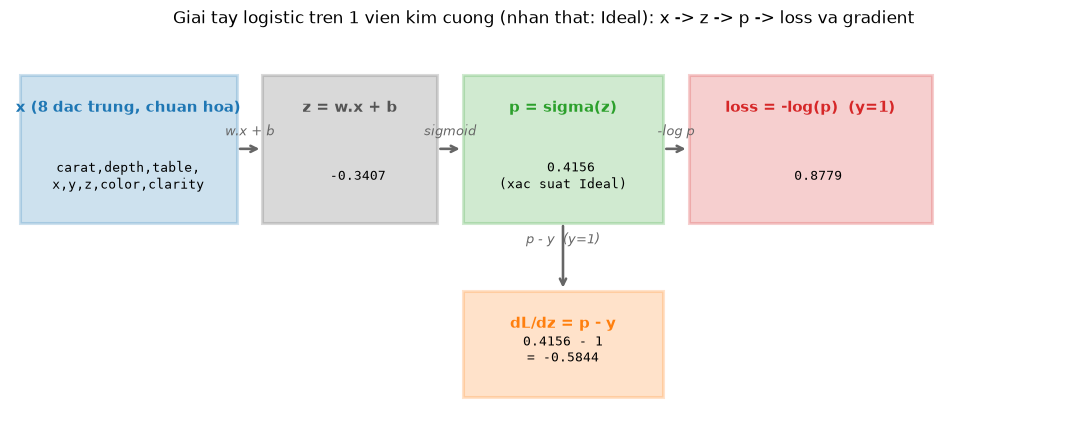

In [3]:
# === So do giai tay (anh nhung trong notebook de xem) ===
fig, ax = plt.subplots(figsize=(12.5, 4.6))
ax.set_xlim(0, 12.5); ax.set_ylim(0, 4.6); ax.axis("off")

def box(x, y, w, h, title, body, color):
    ax.add_patch(plt.Rectangle((x, y), w, h, fill=True, facecolor=color,
                               alpha=0.22, edgecolor=color, lw=2))
    ax.text(x + w/2, y + h - 0.30, title, ha="center", va="top",
            fontsize=10, fontweight="bold", color=color)
    ax.text(x + w/2, y + 0.55, body, ha="center", va="center",
            fontsize=8.7, family="monospace")

def arrow(x1, y1, x2, y2, label):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.7, color="#666"))
    ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.16, label, ha="center",
            fontsize=8.5, color="#666", style="italic")

ytop, h = 2.35, 1.75
box(0.10, ytop, 2.55, h, "x (8 dac trung, chuan hoa)", "carat,depth,table,\nx,y,z,color,clarity", "#1f77b4")
box(2.95, ytop, 2.05, h, "z = w.x + b", "  -0.3407", "#555555")
box(5.30, ytop, 2.35, h, "p = sigma(z)", "  0.4156\n(xac suat Ideal)", "#2ca02c")
box(7.95, ytop, 2.85, h, "loss = -log(p)  (y=1)", "  0.8779", "#d62728")
arrow(2.65, ytop + h/2, 2.95, ytop + h/2, "w.x + b")
arrow(5.00, ytop + h/2, 5.30, ytop + h/2, "sigmoid")
arrow(7.65, ytop + h/2, 7.95, ytop + h/2, "-log p")
box(5.30, 0.30, 2.35, 1.25, "dL/dz = p - y", "0.4156 - 1\n= -0.5844", "#ff7f0e")
arrow(6.475, ytop, 6.475, 1.55, "p - y  (y=1)")
ax.set_title("Giai tay logistic tren 1 vien kim cuong (nhan that: Ideal): x -> z -> p -> loss va gradient",
             fontsize=11, pad=6)
plt.show()

## 4. Giai đoạn 2 — BẢN THUẦN (NumPy duy nhất, không thư viện ML)

Cài đặt trực tiếp từ công thức Mục 3:
- **Nhãn `y_bin` đã là số 0/1** — không cần one-hot như softmax.
- **Gradient descent nguyên bản**, cập nhật $w \leftarrow w - \eta\,\partial\mathcal{L}/\partial w$, `lr=0.5`, `epochs=2000`.
- Đánh giá bằng **accuracy, precision, recall, F1** và **ma trận nhầm lẫn** (tự viết, không dùng `sklearn.metrics`, để nhất quán dùng lại cho cả 3 giai đoạn).

BAN THUAN: acc=0.7941  f1=0.7375  precision=0.7519  recall=0.7237 | loss cuoi=0.4357 | thoi gian=2.851s
He so w (ban thuan):
 [ 0.0077 -0.748  -2.2408 -0.2757  0.3207 -0.0824 -0.006   0.2649]
Thien lech b (ban thuan): -0.8251


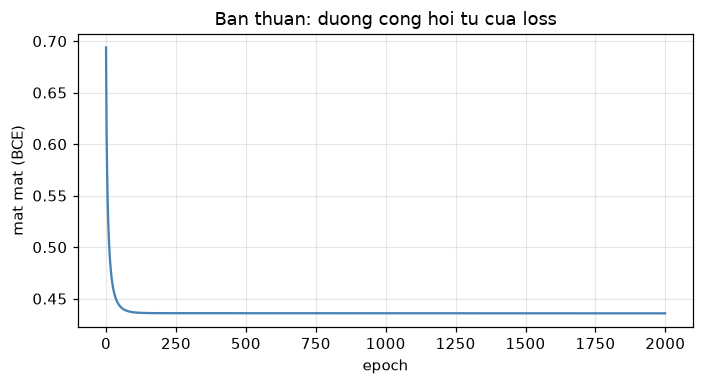

In [4]:
def loss_and_grad_bin(w, b, X, y):
    z = X @ w + b
    p = sigmoid(z)
    n = len(X)
    eps = 1e-12
    L = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    gw = X.T @ (p - y) / n
    gb = (p - y).mean()
    return L, gw, gb

def train_logreg_pure(X, y, lr=0.5, epochs=2000, seed=0):
    """Logistic regression bang GD nguyen ban - chi dung NumPy."""
    rng = np.random.default_rng(seed)
    w = rng.normal(size=X.shape[1]) * 0.01
    b = 0.0
    history = []
    for _ in range(epochs):
        L, gw, gb = loss_and_grad_bin(w, b, X, y)
        history.append(L)
        w -= lr * gw
        b -= lr * gb
    return w, b, history

def predict_proba(w, b, X):
    return sigmoid(X @ w + b)

def predict_bin(w, b, X, thresh=0.5):
    return (predict_proba(w, b, X) >= thresh).astype(int)

def binary_metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    acc = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    cm = np.array([[tn, fp], [fn, tp]])
    return dict(acc=acc, precision=prec, recall=rec, f1=f1, cm=cm)

t0 = time.perf_counter()
w_p, b_p, hist_p = train_logreg_pure(Xtr_s, btr.astype(float), lr=0.5, epochs=2000)
t_pure = time.perf_counter() - t0
pred_te_p = predict_bin(w_p, b_p, Xte_s)
m_p = binary_metrics(bte, pred_te_p)
print("BAN THUAN: acc=%.4f  f1=%.4f  precision=%.4f  recall=%.4f | loss cuoi=%.4f | thoi gian=%.3fs"
      % (m_p["acc"], m_p["f1"], m_p["precision"], m_p["recall"], hist_p[-1], t_pure))
print("He so w (ban thuan):\n", np.round(w_p, 4))
print("Thien lech b (ban thuan):", round(b_p, 4))

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(hist_p, color="steelblue"); ax.set_xlabel("epoch"); ax.set_ylabel("mat mat (BCE)")
ax.set_title("Ban thuan: duong cong hoi tu cua loss"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

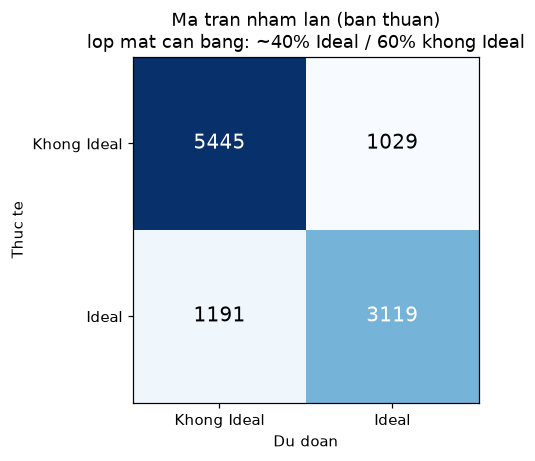

In [5]:
# === Ma tran nham lan (ban thuan, tap test) ===
fig, ax = plt.subplots(figsize=(4.7, 4.3))
cm = m_p["cm"]
ax.imshow(cm, cmap="Blues")
tick_labels = ["Khong Ideal", "Ideal"]
ax.set_xticks([0, 1]); ax.set_xticklabels(tick_labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(tick_labels)
ax.set_xlabel("Du doan"); ax.set_ylabel("Thuc te")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                fontsize=13, color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title("Ma tran nham lan (ban thuan)\nlop mat can bang: ~%.0f%% Ideal / %.0f%% khong Ideal"
             % (100 * bte.mean(), 100 * (1 - bte.mean())))
fig.tight_layout(); plt.show()

## 5. Giai đoạn 3 — BẢN THƯ VIỆN (scikit-learn)

`LogisticRegression` mặc định dùng solver LBFGS (bậc hai) với chính quy hoá L2 nhẹ (`C=1`). Về **độ đo** (accuracy, F1, precision, recall), bản thuần (GD bậc một) và bản lib hội tụ tới kết quả **gần như giống hệt nhau** — xác nhận bản thuần cài đúng. Nhưng bản thân **từng trọng số `w_j`** có thể KHÔNG trùng khớp — in `max|w_pure - w_lib|` bên dưới để xem thực tế, và Mục 8 sẽ giải thích trung thực vì sao (đa cộng tuyến giữa `carat` và `x, y, z`).

In [6]:
from sklearn.linear_model import LogisticRegression

t0 = time.perf_counter()
clf = LogisticRegression(max_iter=1000).fit(Xtr_s, btr)
t_lib = time.perf_counter() - t0
pred_te_l = clf.predict(Xte_s)
m_l = binary_metrics(bte, pred_te_l)
print("BAN LIB (sklearn):  acc=%.4f  f1=%.4f  precision=%.4f  recall=%.4f | thoi gian=%.4fs"
      % (m_l["acc"], m_l["f1"], m_l["precision"], m_l["recall"], t_lib))

w_lib = clf.coef_.ravel()
b_lib = clf.intercept_[0]
print("He so w (sklearn):\n", np.round(w_lib, 4))
print("Thien lech b (sklearn):", round(b_lib, 4))
print("\nSo sanh trong so:  max|w_pure - w_lib| = %.4f   |b_pure - b_lib| = %.4f"
      % (np.abs(w_p - w_lib).max(), abs(b_p - b_lib)))

corr_cx = np.corrcoef(Xtr_s[:, 0], Xtr_s[:, 3])[0, 1]
corr_cy = np.corrcoef(Xtr_s[:, 0], Xtr_s[:, 4])[0, 1]
print("Tuong quan carat-x = %.4f, carat-y = %.4f  (da cong tuyen RAT cao)" % (corr_cx, corr_cy))
print("=> metric gan nhu giong het, nhung w khac nhau nhieu o cac chieu carat/x/y")
print("   vi nhieu to hop (w_carat, w_x, w_y) cho CUNG mot z = w.x -> cung mot ranh gioi quyet dinh.")

BAN LIB (sklearn):  acc=0.7944  f1=0.7376  precision=0.7528  recall=0.7230 | thoi gian=0.0821s
He so w (sklearn):
 [ 0.031  -0.7443 -2.2343 -1.7532  1.7805 -0.0827 -0.0056  0.2582]
Thien lech b (sklearn): -0.8267

So sanh trong so:  max|w_pure - w_lib| = 1.4775   |b_pure - b_lib| = 0.0015
Tuong quan carat-x = 0.9779, carat-y = 0.9704  (da cong tuyen RAT cao)
=> metric gan nhu giong het, nhung w khac nhau nhieu o cac chieu carat/x/y
   vi nhieu to hop (w_carat, w_x, w_y) cho CUNG mot z = w.x -> cung mot ranh gioi quyet dinh.


## 6. Giai đoạn 4 — BẢN FRAMEWORK (PyTorch) — cuối cùng

`nn.Linear(8,1)` tính đúng $z = w\cdot x + b$; `BCEWithLogitsLoss` gộp sigmoid + entropy chéo nhị phân trong một bước ổn định số (tránh tính `log(sigmoid(z))` trực tiếp có thể tràn số). Dùng cùng `lr=0.5`, `epochs=2000` như bản thuần để so sánh công bằng.

In [7]:
import torch
import torch.nn as nn

torch.manual_seed(0)
Xtr_t = torch.tensor(Xtr_s, dtype=torch.float64)
Xte_t = torch.tensor(Xte_s, dtype=torch.float64)
ytr_t = torch.tensor(btr, dtype=torch.float64).view(-1, 1)

model_f = nn.Linear(8, 1).double()
opt = torch.optim.SGD(model_f.parameters(), lr=0.5)
crit = nn.BCEWithLogitsLoss()

t0 = time.perf_counter()
hist_f = []
for _ in range(2000):
    opt.zero_grad()
    logits = model_f(Xtr_t)
    loss = crit(logits, ytr_t)
    loss.backward()
    opt.step()
    hist_f.append(loss.item())
t_fw = time.perf_counter() - t0

with torch.no_grad():
    p_te_f = torch.sigmoid(model_f(Xte_t)).numpy().ravel()
pred_te_f = (p_te_f >= 0.5).astype(int)
m_f = binary_metrics(bte, pred_te_f)
print("BAN FW (PyTorch, SGD):  acc=%.4f  f1=%.4f  precision=%.4f  recall=%.4f | loss cuoi=%.4f | thoi gian=%.3fs"
      % (m_f["acc"], m_f["f1"], m_f["precision"], m_f["recall"], hist_f[-1], t_fw))
w_fw = model_f.weight.detach().numpy().ravel()
print("Trong so w (torch):\n", np.round(w_fw, 4))

BAN FW (PyTorch, SGD):  acc=0.7940  f1=0.7373  precision=0.7517  recall=0.7234 | loss cuoi=0.4357 | thoi gian=2.115s
Trong so w (torch):
 [ 0.0156 -0.7487 -2.2407 -0.337   0.3711 -0.079  -0.0059  0.2645]


## 7. So sánh ba giai đoạn

Cùng dữ liệu, cùng phân chia, cùng chuẩn hoá, cùng `lr=0.5, epochs=2000` (thuần và framework) — so sánh 4 chỉ số trên tập test.

Phuong an                  | acc      | f1       | precision  | recall  
------------------------------------------------------------------------
Ban thuan (NumPy, GD)      | 0.7941   | 0.7375   | 0.7519     | 0.7237  
Ban lib (sklearn, LBFGS)   | 0.7944   | 0.7376   | 0.7528     | 0.7230  
Ban fw (PyTorch, SGD)      | 0.7940   | 0.7373   | 0.7517     | 0.7234  


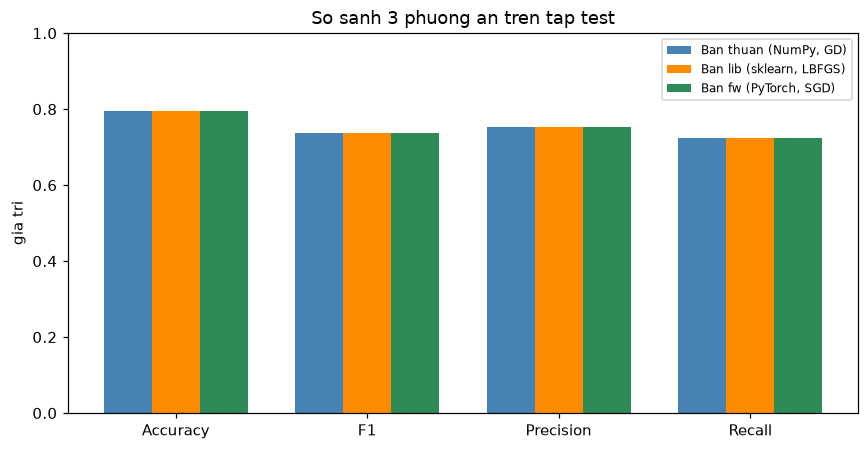

In [8]:
rows = [
    ("Ban thuan (NumPy, GD)",    m_p),
    ("Ban lib (sklearn, LBFGS)", m_l),
    ("Ban fw (PyTorch, SGD)",    m_f),
]
print("%-26s | %-8s | %-8s | %-10s | %-8s" % ("Phuong an", "acc", "f1", "precision", "recall"))
print("-" * 72)
for name, m in rows:
    print("%-26s | %-8.4f | %-8.4f | %-10.4f | %-8.4f" % (name, m["acc"], m["f1"], m["precision"], m["recall"]))

metric_keys = ["acc", "f1", "precision", "recall"]
metric_labels = ["Accuracy", "F1", "Precision", "Recall"]
xpos = np.arange(len(metric_keys))
width = 0.25
colors = ["steelblue", "darkorange", "seagreen"]

fig, ax = plt.subplots(figsize=(8, 4.2))
for i, (name, m) in enumerate(rows):
    vals = [m[k] for k in metric_keys]
    ax.bar(xpos + (i - 1) * width, vals, width, label=name, color=colors[i])
ax.set_xticks(xpos); ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.0); ax.set_ylabel("gia tri")
ax.set_title("So sanh 3 phuong an tren tap test")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 8. Thảo luận trung thực — vì sao logistic hội tụ sạch hơn hồi quy giá?

Notebook hồi quy tuyến tính (nhãn `price`, dùng **cùng ma trận đặc trưng** X 8 cột) cần tới **30000 epoch** (`lr=0.1`) để bản thuần khớp bản thư viện, vì:
- Ma trận đặc trưng X có đa cộng tuyến vừa phải (`carat` tương quan cao với `x, y, z`) — condition number sau chuẩn hoá $\approx 624$, khiến mặt lỗi MSE bị "kéo dài" theo một số hướng, gradient descent phải đi rất nhiều bước nhỏ mới hội tụ.
- Nhãn `price` có biên độ hàng nghìn USD, khiến gradient MSE thô ($X^\top(X w - y)$) rất lớn — phải dùng `lr` nhỏ và nhiều epoch để tránh phân kỳ.

Ở notebook Logistic này, **cùng ma trận X** đó (cùng đa cộng tuyến) chỉ cần **2000 epoch** với `lr=0.5` để đạt độ đo (accuracy, F1) gần như giống hệt bản thư viện — nhanh hơn nhiều so với 30000 epoch của hồi quy giá. Nhưng cần trung thực về một điểm khác: nhìn `max|w_pure - w_lib|` in ở Mục 5 sẽ thấy con số này **không hề nhỏ** (thường trên 1.0) — trọng số học được KHÔNG trùng khớp, dù độ đo phân loại thì có. Đây là hai hiện tượng khác nhau, cần tách bạch:

**(A) Vì sao ĐỘ ĐO hội tụ nhanh (2000 so với 30000 epoch):**
1. **Gradient bị chặn.** Với hồi quy logistic, $\partial\ell/\partial z = p - y$ luôn nằm trong khoảng $[-1, 1]$ vì $p \in (0,1), y\in\{0,1\}$ — bất kể đặc trưng lớn/nhỏ ra sao. Ngược lại, gradient MSE của hồi quy giá tỉ lệ thuận với sai số (giá) tính bằng nghìn USD — không hề bị chặn, cần `lr` rất nhỏ và rất nhiều epoch để không phân kỳ.
2. **Mặt lỗi "phẳng" hơn.** Hessian của entropy chéo qua sigmoid là $X^\top \mathrm{diag}(p(1-p))\,X/N$; vì $p(1-p)\le 0.25$ với mọi $p$, độ cong này luôn nhỏ hơn (hoặc bằng) độ cong $X^\top X/N$ của MSE — sigmoid "làm dịu" ảnh hưởng của thang đo/đa cộng tuyến lên tốc độ hội tụ của GD.

**(B) Vì sao TRỌNG SỐ vẫn không trùng khớp (không giấu diếm):** `carat` tương quan với `x` khoảng 0.98 và với `y` khoảng 0.97 (in ở Mục 5) — cực kỳ cao. Khi hai (hoặc nhiều) cột gần như là bản sao tuyến tính của nhau, hàm mất mát gần như KHÔNG đổi khi "chuyển" một lượng trọng số từ cột này sang cột kia (miễn tổng đóng góp vào $z=w\cdot x$ không đổi) — bài toán tối ưu có một **hướng gần-phẳng** trong không gian trọng số. GD bản thuần (2000 bước, không chính quy hoá) và LBFGS của sklearn (chính quy hoá L2 nhẹ, nhiều bước Newton hơn) dừng lại ở **hai điểm khác nhau dọc theo hướng phẳng đó** — cho gần như cùng một `z` (nên cùng dự đoán, cùng accuracy/F1) nhưng khác nhau đáng kể ở từng hệ số `w_x, w_y` riêng lẻ. Đây là hiện tượng kinh điển của đa cộng tuyến: **dự đoán thì ổn định, nhưng từng hệ số thì không** — không nên diễn giải độ lớn một hệ số hồi quy như "mức độ quan trọng" của đặc trưng đó khi các đặc trưng tương quan cao.

**Về mất cân bằng lớp.** Tập dữ liệu có khoảng 40% "Ideal" / 60% "không Ideal" — mất cân bằng nhẹ, không nghiêm trọng. Ma trận nhầm lẫn (Mục 4) cho thấy mô hình vẫn dự đoán tốt cả hai lớp; nếu mất cân bằng nặng hơn (vd 95/5), accuracy sẽ gây hiểu lầm và cần theo dõi F1/recall của lớp thiểu số sát hơn.

## 9. Kết luận

- **Ba phương án cho kết quả gần như giống hệt nhau** (accuracy ≈ 0.79, F1 ≈ 0.74) — xác nhận bản thuần cài **đúng công thức** ở Mục 3.
- **Bản thuần (GD nguyên bản)** hội tụ nhanh (2000 epoch) mà không cần thủ thuật gì thêm — vì hàm mất mát logistic vốn có gradient bị chặn, ít nhạy với đa cộng tuyến hơn MSE.
- **Nhưng trọng số học được thì KHÔNG trùng khớp** giữa 3 phương án (Mục 8B) — đa cộng tuyến giữa `carat, x, y` khiến bài toán có vô số nghiệm `w` gần-tối-ưu tương đương; chỉ riêng "dự đoán" (và do đó accuracy/F1) mới đáng tin cậy để so sánh, không nên diễn giải từng hệ số riêng lẻ.
- **Bản lib/framework** cho kết quả tương đương nhưng ổn định hơn về mặt kỹ thuật (solver bậc hai, autograd) — phù hợp dùng trong thực tế.
- So với bài hồi quy giá (cùng đặc trưng X), đây là minh chứng thực nghiệm rằng **loss function quyết định độ khó hội tụ** không kém gì bản thân dữ liệu đầu vào — nhưng đa cộng tuyến vẫn để lại dấu ấn của nó, chỉ là ở khía cạnh khác (định danh trọng số) thay vì tốc độ hội tụ.